# 01. The logistic map

Here is a model simple enough to write on a napkin that still manages to go
chaotic. The logistic map takes a fraction `x` in `[0, 1]` and updates it each
generation by

$$ x_{n+1} = r\, x_n (1 - x_n), $$

where `r` is the growth rate: the linear term `r x` is growth, the quadratic
term is the crowding that holds it back. For `r` up to 4 the unit interval maps
into itself, so the iterates stay bounded. What changes with `r` is the *shape*
of the long-run behaviour: a steady state, then a cycle of period two, four,
eight, and eventually chaos. This notebook follows single trajectories at a few
growth rates, makes the iteration geometric with a cobweb construction, and
sweeps `r` to preview the period-doubling cascade that notebook 02 maps out in
full.

The trajectories and the sweep are computed in `scripts/run_logistic.py` and
read back here from `artifacts/`. The map curve and the cobweb are drawn
directly, since they are closed-form illustrations rather than experiments.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from nldynamics.logistic import cobweb, logistic_map
from nldynamics.plotting import palette, setup_style


def project_root() -> Path:
    for parent in [Path.cwd(), *Path.cwd().parents]:
        if (parent / "pyproject.toml").exists() and (parent / "src" / "nldynamics").exists():
            return parent
    return Path.cwd()


setup_style()
ROOT = project_root()
data = np.load(ROOT / "artifacts" / "logistic.npz")
regime_r = data["regime_r"]
trajectories = data["trajectories"]

## The map and its fixed points

Before the chaos, the fixed points. A fixed point satisfies `x = r x (1 - x)`:
there is always `x* = 0`, and for `r > 1` a second one at `x* = 1 - 1/r`. The
map is a downward parabola, and where it crosses the diagonal `y = x` is a fixed
point. The slope of the parabola there decides everything, whether nearby states
are drawn in or pushed away. The non-trivial fixed point is stable while
`|2 - r| < 1`, that is for `1 < r < 3`.

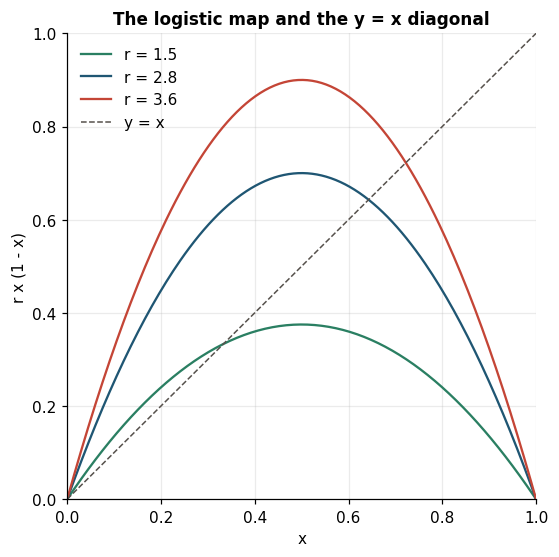

In [2]:
x = np.linspace(0, 1, 200)
fig, ax = plt.subplots(figsize=(5.5, 5.5))
for r, colour in ((1.5, palette("stable")), (2.8, palette("orbit")), (3.6, palette("chaotic"))):
    ax.plot(x, logistic_map(r, x), color=colour, label=f"r = {r}")
ax.plot([0, 1], [0, 1], color=palette("diagonal"), lw=1.0, ls="--", label="y = x")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_xlabel("x")
ax.set_ylabel("r x (1 - x)")
ax.set_title("The logistic map and the y = x diagonal")
ax.legend()
plt.show()

The curve climbs and steepens with `r`. While the parabola meets the diagonal
at a shallow enough slope, the intersection is a stable fixed point. Once that
slope exceeds one in magnitude the fixed point loses stability, and the
dynamics move on to a cycle.

## Single trajectories

The quickest way to see what `r` does is to iterate from a single seed and
watch. A short transient is discarded so the recorded series sits on the
attractor: a constant for a stable fixed point, an alternation for a two-cycle,
and an aperiodic wander for chaos.

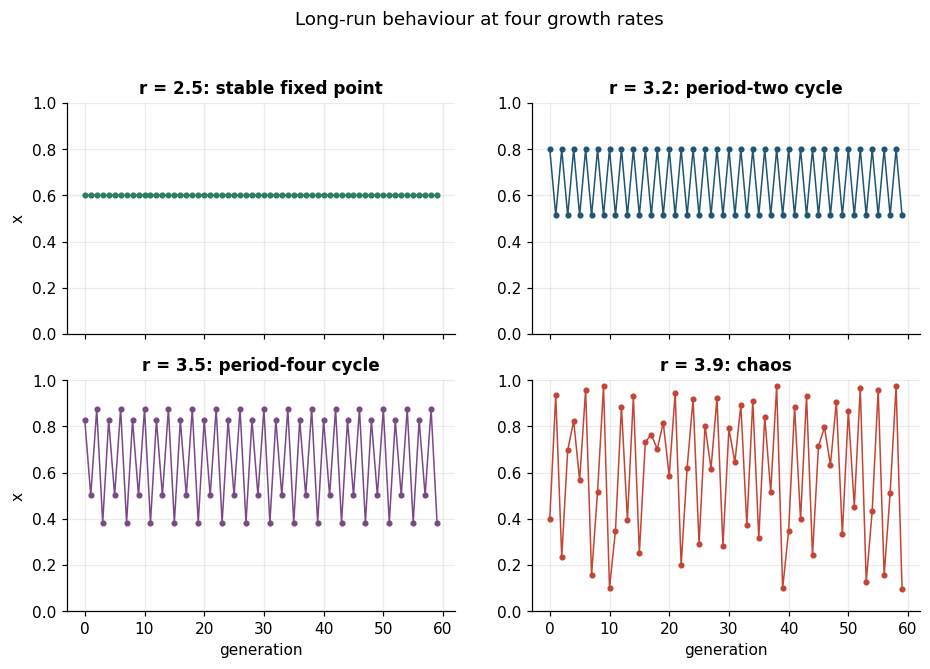

In [3]:
labels = ("stable fixed point", "period-two cycle", "period-four cycle", "chaos")
colours = (palette("stable"), palette("orbit"), palette("accent"), palette("chaotic"))
fig, axes = plt.subplots(2, 2, figsize=(10, 6), sharex=True)
for ax, r, label, colour, trajectory in zip(
    axes.ravel(), regime_r, labels, colours, trajectories, strict=True
):
    ax.plot(trajectory, color=colour, marker="o", ms=3, lw=1.0)
    ax.set_ylim(0, 1)
    ax.set_title(f"r = {r:g}: {label}")
for ax in axes[-1]:
    ax.set_xlabel("generation")
for ax in axes[:, 0]:
    ax.set_ylabel("x")
fig.suptitle("Long-run behaviour at four growth rates", y=1.02)
plt.show()

The four panels are the cascade in miniature: a single settled value, then two
values visited in turn, then four, and finally an orbit that never repeats. The
transitions between these regimes are the bifurcations notebook 02 locates.

## The cobweb construction

The cobweb plot turns the iteration into a picture. Start on the diagonal at
`(x, x)`: a vertical step to the curve gives `(x, f(x))`, then a horizontal step
back to the diagonal gives `(f(x), f(x))`, and the staircase repeats. A stable
fixed point pulls the staircase into a tightening spiral. A chaotic regime fills
a region with a tangle that never closes.

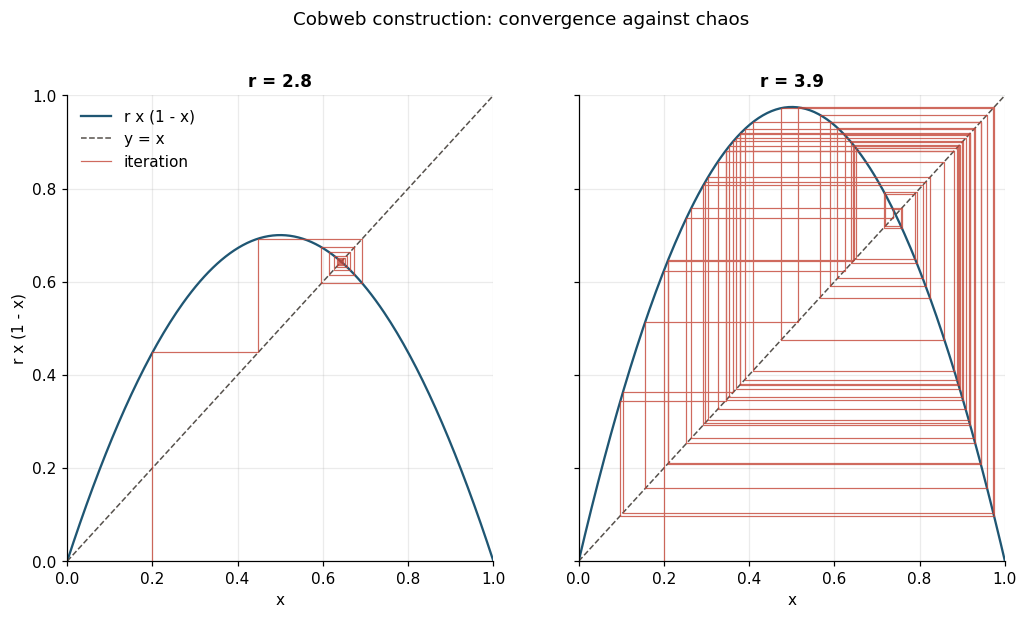

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(11, 5.5), sharey=True)
t = np.linspace(0, 1, 200)
for ax, r in zip(axes, (2.8, 3.9), strict=True):
    ax.plot(t, logistic_map(r, t), color=palette("orbit"), lw=1.5, label="r x (1 - x)")
    ax.plot([0, 1], [0, 1], color=palette("diagonal"), lw=1.0, ls="--", label="y = x")
    xs, ys = cobweb(r, 0.2, n=60)
    ax.plot(xs, ys, color=palette("chaotic"), lw=0.8, alpha=0.8, label="iteration")
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_xlabel("x")
    ax.set_title(f"r = {r}")
axes[0].set_ylabel("r x (1 - x)")
axes[0].legend(loc="upper left")
fig.suptitle("Cobweb construction: convergence against chaos", y=1.02)
plt.show()

The left panel spirals onto the single intersection of curve and diagonal, the
stable fixed point. The right panel never settles: the staircase wanders across
the whole interval, the geometric signature of the chaos seen in the trajectory
above.

## A parameter sweep

One trajectory at a time only gets you so far. Overlaying the late iterates from
a whole fan of growth rates previews the bifurcation diagram: each value of `r`
is iterated past its transient and the remaining points plotted against `r`.
Where a single value persists the behaviour is periodic; where the points spread
it is chaotic.

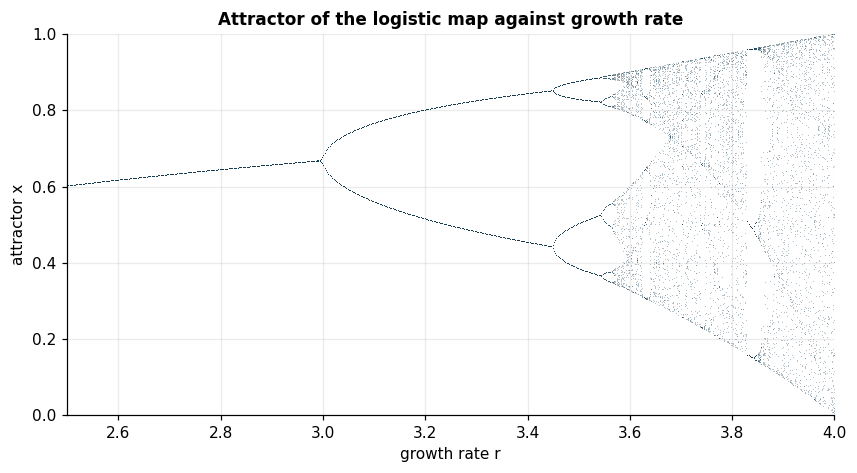

In [5]:
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(data["sweep_r"], data["sweep_x"], ",", color=palette("attractor"), alpha=0.3)
ax.set_xlim(2.5, 4.0)
ax.set_ylim(0, 1)
ax.set_xlabel("growth rate r")
ax.set_ylabel("attractor x")
ax.set_title("Attractor of the logistic map against growth rate")
plt.show()

The single curve splits into two near `r = 3`, into four a little later, and
dissolves into a chaotic band beyond `r ≈ 3.57`, broken by pale vertical
windows where order briefly returns (the widest is the period-three window near
`r = 3.83`). Notebook 02 renders this sweep at higher resolution and pairs it
with the Lyapunov exponent, which measures the chaos.

## Summary

- The logistic map `r x (1 - x)` has a non-trivial fixed point `x* = 1 - 1/r`,
  stable for `1 < r < 3` and lost to a period-two cycle at `r = 3`.
- Single trajectories show the cascade directly: one settled value, then two,
  then four, then an aperiodic orbit as `r` is raised.
- The cobweb construction makes the iteration geometric: a tightening spiral
  onto a stable fixed point, an unclosing tangle in chaos.
- A parameter sweep previews the bifurcation diagram, with chaotic bands and
  narrow periodic windows. Notebook 02 quantifies it with the Lyapunov
  exponent.